## Cancer type panel: body with labelled sites

Atlas cell lines by cancer type, from `../pccma_cell_line_metadata.csv`, shown on an anatomical body drawn with
[gganatogram](https://github.com/jespermaag/gganatogram) (Maag 2018, GPL-2). Organs are filled by tumor site; small
organs get a translucent halo, and the eyes (not an organ in the package) are marked directly. The body illustrates the
typical site of each tumor type and is not anatomical detail. gganatogram only ships adult bodies, so the body is
reshaped to child proportions (larger head, shorter legs, narrower frame; see `plotting_helpers/cell_line_figure_utils.R`) while the organ shapes stay adult. All text sits to the right of the body: each tumor site
gets a header with its cell line total, then each cancer group in bold with its count, followed by the cell lines
themselves. Text takes the colour of the tumor site (slightly darkened so it stays legible on white).

The 23 raw `cancer_type` labels are combined into cancer groups and tumor sites in `plotting_helpers/cancer_type_categories.yaml`, and the
names shown for cell lines come from `plotting_helpers/cell_line_display_names.csv` (edit either file to change the figure). Colours live in
the repo-level `themes.R`; organ/marker positions live in `plotting_helpers/cell_line_figure_utils.R`.

`gganatogram` is not on CRAN or conda-forge; install it once with
`devtools::install_github("jespermaag/gganatogram")`.

In [1]:
suppressPackageStartupMessages({
  library(patchwork)
  library(stringr)
})

source(file.path("..", "plotting_helpers", "cell_line_figure_utils.R"))

metadata_file <- file.path("..", "pccma_cell_line_metadata.csv")
categories_file <- file.path("..", "plotting_helpers", "cancer_type_categories.yaml")
output_dir <- "figures"
dir.create(output_dir, showWarnings = FALSE, recursive = TRUE)

### Load and count

`U2-OS` was run under several plate conditions and has one row per condition, so each cell line is counted once.
Cell lines are counted per cancer group and per tumor site.

In [2]:
atlas <- prepare_cancer_type_data(metadata_file, categories_file)
group_counts <- atlas$group_counts
site_counts <- atlas$site_counts

print(as.data.frame(group_counts), row.names = FALSE)
cat("\nTotal:", sum(group_counts$n), "cell lines\n")

members <- atlas$cell_lines %>%
  group_by(site, cancer_group) %>%
  summarise(cancer_type_labels = paste(sort(unique(cancer_type)), collapse = "; "),
            cell_lines = paste(sort(cell_line), collapse = ", "), .groups = "drop")
print(as.data.frame(members), row.names = FALSE, right = FALSE)

                   site                              cancer_group  n
          Adrenal gland                             Neuroblastoma 12
                   Bone                      Ewing sarcoma family  8
                   Bone                              Osteosarcoma  4
 Central nervous system                           Medulloblastoma  5
 Central nervous system                                    Glioma  4
 Central nervous system          Atypical teratoid rhabdoid tumor  1
 Central nervous system                                Ependymoma  1
            Soft tissue                          Rhabdomyosarcoma  7
            Soft tissue                   Myoepithelial carcinoma  2
                    Eye                            Retinoblastoma  4
                 Kidney                  Malignant rhabdoid tumor  2
                 Kidney                               Wilms tumor  1
                  Ovary                           Germ cell tumor  1
 Normal reference lines Normal (co


Total: 56 cell lines


 site                   cancer_group                             
 Adrenal gland          Neuroblastoma                            
 Bone                   Ewing sarcoma family                     
 Bone                   Osteosarcoma                             
 Central nervous system Atypical teratoid rhabdoid tumor         
 Central nervous system Ependymoma                               
 Central nervous system Glioma                                   
 Central nervous system Medulloblastoma                          
 Eye                    Retinoblastoma                           
 Kidney                 Malignant rhabdoid tumor                 
 Kidney                 Wilms tumor                              
 Normal reference lines Normal (colon, lung, microglia, prostate)
 Ovary                  Germ cell tumor                          
 Soft tissue            Myoepithelial carcinoma                  
 Soft tissue            Rhabdomyosarcoma                         
 cancer_ty

### Body with labelled sites

Each label block is placed near its organ (blocks are pushed apart where they would overlap) and joined to the organ by a
leader line. Cell line lines are wrapped to balanced widths, and the figure is cropped to the body and text, so the
size follows from the content (`units_per_inch` sets the text size relative to the body).

figure size: 7.98 x 9.78 in; text bottom -192.5 vs feet -194.8


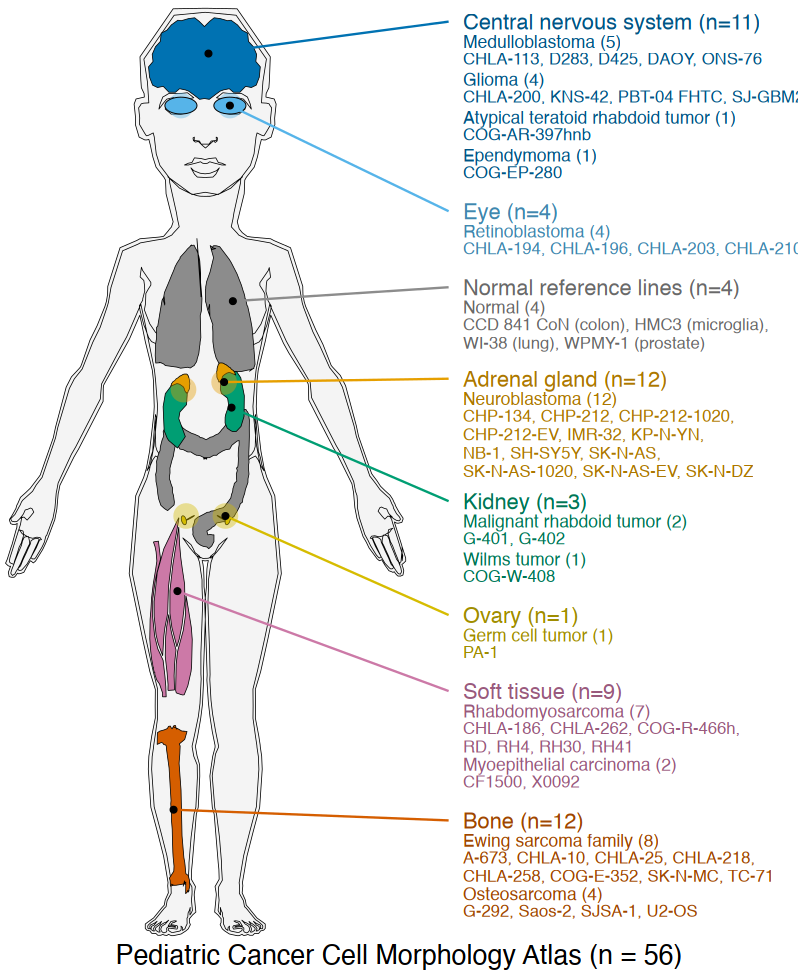

In [3]:
max_width <- 42        # widest line of cell line text, in characters
header_height <- 5.6   # plot units taken by a site header
group_row <- 3.7       # plot units taken by a bold cancer group line
names_pitch <- 3.25    # plot units per line of cell line names
group_gap <- 1         # plot units between cancer groups within a block
block_gap <- 2.4       # plot units between blocks
gap_to_text <- 12      # plot units between the body and the text column
units_per_inch <- 21   # plot units per inch: sets the text size relative to the body
margin_pt <- 4         # white margin around the figure
caption_size <- 19     # font size (pt) of the atlas label centred under the figure; it adds to the figure height
caption_gap <- 6       # pt between the panel and the label

# wrap to as few lines as fit max_width, then to the narrowest width that still gives that many lines (balanced lines)
balanced_wrap <- function(x, max_width) {
  n_lines <- str_count(str_wrap(x, width = max_width), "\n") + 1
  for (w in seq(10, max_width)) {
    wrapped <- str_wrap(x, width = w)
    if (str_count(wrapped, "\n") + 1 == n_lines) return(wrapped)
  }
}

body <- body_extent()
text_x <- body$xlim[2] + gap_to_text
y_top <- body$ylim[2]

# one entry per cancer group: bold "Group (n)" line, then its cell lines wrapped underneath
cell_line_text <- atlas$cell_lines %>%
  mutate(display_name = factor(display_name, levels = str_sort(unique(display_name), numeric = TRUE))) %>%
  arrange(display_name) %>%
  group_by(site, cancer_group) %>%
  summarise(names = paste(display_name, collapse = ", "), .groups = "drop") %>%
  left_join(group_counts, by = c("site", "cancer_group")) %>%
  rowwise() %>%
  mutate(names_text = balanced_wrap(names, max_width)) %>%
  ungroup() %>%
  mutate(group_label = paste0(str_remove(cancer_group, " \\(.*\\)$"), " (", n, ")"),
         names_lines = str_count(names_text, "\n") + 1,
         height = group_row + names_pitch * names_lines + group_gap) %>%
  arrange(site, desc(n), cancer_group)

blocks <- site_info %>%
  filter(site %in% site_counts$site) %>%
  left_join(site_counts, by = "site") %>%
  mutate(
    height = header_height + sapply(site, function(s) sum(cell_line_text$height[cell_line_text$site == s])),
    header = paste0(site, " (n=", n, ")"),
    text_colour = unname(site_text_colors[site])
  ) %>%
  arrange(desc(anchor_y))

# centre each block on its organ, then push blocks apart from the top
blocks$top <- blocks$anchor_y + blocks$height / 2
blocks$top[1] <- min(blocks$top[1], y_top)
for (i in seq_len(nrow(blocks))[-1]) {
  blocks$top[i] <- min(blocks$top[i], blocks$top[i - 1] - blocks$height[i - 1] - block_gap)
}
blocks <- blocks %>% mutate(header_y = top - header_height / 2)

# top of each cancer group line within its block
cell_line_text <- cell_line_text %>%
  left_join(blocks %>% select(site, top, text_colour), by = "site") %>%
  group_by(site) %>%
  mutate(group_y = top - header_height - (cumsum(height) - height)) %>%
  ungroup() %>%
  mutate(names_y = group_y - group_row)

# crop to the body and the text: approximate width of the longest line of each style (plot units per character)
longest_names <- max(nchar(unlist(strsplit(cell_line_text$names_text, "\n"))))
text_right <- text_x + max(longest_names * 1.82, max(nchar(cell_line_text$group_label)) * 1.75,
                           max(nchar(blocks$header)) * 2.25)
x_lim <- c(body$xlim[1], text_right)
y_lim <- c(min(body$ylim[1], min(blocks$top - blocks$height) + 1.8), max(body$ylim[2], max(blocks$top)))  # +1.8: slack under the last line
fig_width <- diff(x_lim) / units_per_inch + 2 * margin_pt / 72
fig_height <- diff(y_lim) / units_per_inch + 2 * margin_pt / 72 + (caption_size * 1.2 + caption_gap) / 72

panel <- draw_body(site_counts$site) + body_markers(site_counts$site) +
  geom_segment(data = blocks, aes(x = anchor_x, y = anchor_y, xend = text_x - 3, yend = header_y, colour = colour),
               linewidth = 0.6, inherit.aes = FALSE) +
  geom_point(data = blocks, aes(x = anchor_x, y = anchor_y), size = 1.6, colour = "black", inherit.aes = FALSE) +
  geom_text(data = blocks, aes(x = text_x, y = header_y, label = header, colour = text_colour),
            hjust = 0, fontface = "bold", size = 5.4, inherit.aes = FALSE) +
  geom_text(data = cell_line_text, aes(x = text_x, y = group_y, label = group_label, colour = text_colour),
            hjust = 0, vjust = 1, fontface = "bold", size = 4.3, inherit.aes = FALSE) +
  geom_text(data = cell_line_text, aes(x = text_x, y = names_y, label = names_text, colour = text_colour),
            hjust = 0, vjust = 1, size = 4.1, lineheight = 0.95, inherit.aes = FALSE) +
  scale_colour_identity() +
  coord_fixed(xlim = x_lim, ylim = y_lim, expand = FALSE, clip = "off") +
  labs(caption = paste0("Pediatric Cancer Cell Morphology Atlas (n = ", nrow(atlas$cell_lines), ")")) +
  annotation_theme(margin_pt, caption_size, caption_gap)

options(repr.plot.width = fig_width, repr.plot.height = fig_height, repr.plot.res = 100)
cat(sprintf("figure size: %.2f x %.2f in; text bottom %.1f vs feet %.1f\n", fig_width, fig_height,
            min(blocks$top - blocks$height), body$ylim[1]))
panel

### Save

In [4]:
ggsave(file.path(output_dir, "cancer_type_anatogram_labels.png"), panel, width = fig_width, height = fig_height, dpi = 300, bg = "white")
ggsave(file.path(output_dir, "cancer_type_anatogram_labels.pdf"), panel, width = fig_width, height = fig_height)
list.files(output_dir, pattern = "cancer_type_anatogram_labels")

[1] "cancer_type_anatogram_labels.pdf" "cancer_type_anatogram_labels.png"